In [73]:
# --- IMPORT STATEMENTS ---

import numpy as np

import matplotlib.pyplot as plt

from scipy import constants

from astropy.io import fits
from astropy.wcs import WCS

import healpy as hp

In [74]:
# idea: treat GDIGS separately, cut data (minimal) to hard-coded L_BOUNDS and B_BOUNDS, then use those bounds in rebin_GDIGS() function

In [75]:
# --- GLOBAL VARIABLES ---

LINUX_DIRECTORY = "/home/aimee/mphys" # Aimee
FIGURE_SAVEDIR = "figures/masking" # Aimee
MASKED_MAPS_SAVEDIR = f'{LINUX_DIRECTORY}/data/masked_maps' # Aimee
GDIGS_MOSAIC_DIR = f"{LINUX_DIRECTORY}/data/GDIGS_mosaic" # Aimee
OTHER_MAPS_DIR = f'{LINUX_DIRECTORY}/data/maps' # Aimee
# LINUX_DIRECTORY = '/home/u20482jg/MPHYS_Project_Local' # Joe
# FIGURE_SAVEDIR = f'figures/masking' # Joe
# MASKED_MAPS_SAVEDIR = f'{LINUX_DIRECTORY}/data/all_maps/masked_maps' # Joe
# GDIGS_MOSAIC_DIR = f"{LINUX_DIRECTORY}/data/GDIGS_Mosaics" # Joe
# OTHER_MAPS_DIR = f'{LINUX_DIRECTORY}/data/all_maps/maps' # Joe

SAVE_FIGS = True

SNR_CSV_PATH = f'{LINUX_DIRECTORY}/data/SNR_locations_final.csv'
PS_CSV_PATH = f"{LINUX_DIRECTORY}/data/Effelsberg_2.73GHz_(5'_smoothed)_point_sources_final.csv"

# # Effelsberg limits masking range - see find_point_sources_v2.ipynb
# L_BOUNDS = [-5, 90] # degrees (no cutting in l direction)
# B_BOUNDS = [-4, 4] # degrees (cut off above +- 4 deg in l direction - weird false point sources at b ~ +-5)
# only for GDIGS
L_BOUNDS = [0, 32] # degrees
B_BOUNDS = [-1.5, 1.5] # degrees

STEP = 0.0083333333333333 # original GDIGS pixel size in degrees (1/2 arcmin) (exact from header)
STEP = 1/60

# Locating point sources (tweak) - see locate_point_sources()
FWHM_PS = 5
THRESHOLD_FACTOR = 0.8

# Maps and locations
GDIGS_MAPS = {
    "GDIGS Moment 0" : ['gdigs_moment0_mosaic.fits', 0] # TEMP FREQUENCY
    } 

COMAP_MAPS = { # name : [file name, frequency / Hz]
    "COMAP 26.5 GHz" : ["comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 26.5e9],
    "COMAP 27.5 GHz" : ["comap_alr-2_galactic_301025_band01_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 27.5e9],
    "COMAP 28.5 GHz" : ["comap_alr-2_galactic_301025_band02_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 28.5e9],
    "COMAP 29.5 GHz" : ["comap_alr-2_galactic_301025_band03_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 29.5e9],
    "COMAP 30.5 GHz" : ["comap_alr-2_galactic_301025_band04_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 30.5e9],
    "COMAP 31.5 GHz" : ["comap_alr-2_galactic_301025_band05_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 31.5e9],
    "COMAP 32.5 GHz" : ["comap_alr-2_galactic_301025_band06_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 32.5e9],
    "COMAP 33.5 GHz" : ["comap_alr-2_galactic_301025_band07_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 33.5e9]
}

EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    # "Effelsberg 2.73 GHz" : ['Effelsberg_2.7272GHz_raw.fits',2.7272727272727275e9] # raw from website - 3D WCS (code can't handle it)
    "Effelsberg 2.73 GHz" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits",2.7272727272727275e9] # TJ Rennie's pre-processed map (not ideal, but WCS works)
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
#    "Nobeyama 10 GHz" : ["Nobeyama_10.0GHz_raw.fits",10e9] # raw from website - 3D WCS (code can't handle it)
    "Nobeyama 10 GHz" : ["NOBEYAMA-10.0GHz-5.0amin.fits",10e9] # TJ Rennie's pre-processed map (not ideal, but WCS works)
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    # "Parkes 5 GHz" : ["Parkes_5.0GHz_raw.fits",5e9] # raw from website - 3D WCS (code can't handle it)
    "Parkes 5 GHz" : ["PARKES-5.0GHz-5.0amin.fits",5e9] # CORRUPTED
}



In [76]:
# --- FUNCTION DEFINTIONS ---

In [77]:
def get_map(path):
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)

    try: # COMAP
        noise = fits_file[3].data
    except: # if no original data, returns array of nans w/ same shape as data
        noise = np.zeros_like(data) 
        # noise.fill(np.nan) 
        
    return data, noise, header, wcs

In [78]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = 0 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [mK]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [79]:
def galactic_to_pixel(l_coords, b_coords, WCS):

    x_coords = []
    y_coords = []
    for i, _ in enumerate(l_coords):
        l = l_coords[i] 
        b = b_coords[i]
        
        x, y = WCS.all_world2pix(float(l), float(b), 0)

        x_coords.append(x)
        y_coords.append(y)

    return x_coords, y_coords

In [80]:
def cut_data(data, wcs, header):
    
    lat_min = B_BOUNDS[0]
    lat_max = B_BOUNDS[1]
    long_min = L_BOUNDS[0]
    long_max = L_BOUNDS[1]
    step = header['CDELT2']  # pixel resolution

    # may be off by fraction of pixel
    start_row = int(header['CRPIX2'] + lat_min / step)
    end_row   = int(header['CRPIX2'] + lat_max / step)
    start_col = int(header['CRPIX1'] + (header['CRVAL1'] - long_max) / step)
    end_col   = int(header['CRPIX1'] + (header['CRVAL1'] - long_min) / step)
    
    # Safety check against invalid indices
    nrows, ncols = data.shape
    start_row = max(0, min(nrows - 1, start_row))
    end_row   = max(0, min(nrows - 1, end_row))
    start_col = max(0, min(ncols - 1, start_col))
    end_col   = max(0, min(ncols - 1, end_col))
    
    # Extract and process submap
    submap = data[start_row:end_row + 1, start_col:end_col + 1].copy()
    submap[submap == 0] = np.nan

    wcs.wcs.crpix[0] -= start_col
    wcs.wcs.crpix[1] -= start_row

    header['CRPIX1'] = wcs.wcs.crpix[0]
    header['CRPIX2'] = wcs.wcs.crpix[1]
    
    return submap, wcs, header

In [81]:
# def main(data, wcs, header, noise, map_fname, GDIGS=False, noise_level=0):

#     # Create mask
#     mask = create_mask(data, wcs, map_title=f'{map_fname}', show_plots=False, show_masks=False)

#     # Apply mask
#     data_masked = data.copy()
#     data_masked[mask] = np.nan # change to hp.UNSEEN?
#     plot_fits(data_masked, wcs, title=f'{map_fname} - SNRs and PSs Masked')


#     if GDIGS:
#         # Rebin masked GDIGS (and update wcs, header)
#         factor = 2
#         data_masked, data_masked_wcs, data_masked_header = rebin_GDIGS(data_masked, wcs, header, factor)
#         plot_fits(data_masked, data_masked_wcs, title=f'{map_fname} - Masked and Re-binned')
#     else:
#         data_masked_wcs = wcs
#         data_masked_header = header

#     # Save map
#     hdu_data = fits.PrimaryHDU(data=data_masked, header=data_masked_header) # data - layer 0
#     hdu_noise_1 = fits.ImageHDU(data=noise, name='NOISE') # original noise - layer 1
#     hdu_noise_2 = fits.ImageHDU(data=noise, name='NOISE') # calculated noise - layer 2
#     hdul = fits.HDUList([hdu_data, hdu_noise_1, hdu_noise_2]) # combined

#     hdul.writeto(f"{MASKED_MAPS_SAVEDIR}/{map_fname.replace('.fits', '')}_masked.fits", overwrite=True)



In [82]:
def validate_shapes(submap, map_gids):
    
    if submap.shape == map_gids.shape: # if shapes match, no change needed
        return submap, map_gids
    
    submap_height, submap_width = submap.shape
    map_gids_height, map_gids_width = map_gids.shape

    # Height difference - if 1 or 2 pixels off, delete last 1 or 2 rows of larger map
    height_diff = np.abs(submap_height - map_gids_height)
    if height_diff in [0, 1, 2]:
        if submap_height > map_gids_height: # submap larger than GDIGS
            print(f'Warning: submap {height_diff} pixel(s) taller than GDIGS - removing last {height_diff} row(s) of pixels')
            submap = submap[:-height_diff, :]
        elif map_gids_height > submap_height: # GDIGS larger than submap
            print(f'Warning: GDIGS {height_diff} pixel(s) taller than submap - removing last {height_diff} row(s) of pixels')
            map_gids = map_gids[:-height_diff, :]
    else:
        print(f'Error: incompatible shapes \nGDIGS shape: {map_gids.shape} \nMap shape: {submap.shape}')

    # Width difference - if 1 or 2 pixels off, delete last 1 or 2 columns of larger map
    width_diff = np.abs(submap_width - map_gids_width)
    if width_diff in [0, 1, 2]:
        if submap_width > map_gids_width: # submap larger than GDIGS
            print(f'Warning: submap {width_diff} pixel(s) wider than GDIGS - removing last {width_diff} column(s) of pixels')
            submap = submap[:, :-width_diff]
        elif map_gids_width > submap_width: # GDIGS larger than submap
            print(f'Warning: GDIGS {width_diff} pixel(s) wider than submap - removing last {width_diff} column(s) of pixels')
            map_gids = map_gids[:, :-width_diff]
    else:
        print(f'Error: incompatible shapes \nGDIGS shape: {map_gids.shape} \nMap shape: {submap.shape}')

    return submap, map_gids

In [83]:
def rebin_data(data, factor):
    n_rows, n_cols = data.shape
    # print(f"Original shape: {data.shape}")

    # Crop rows and columns if not divisible by factor
    if n_rows % factor != 0:
        new_n_rows = (n_rows // factor) * factor
        data = data[:new_n_rows, :]
        # print(f"Adjusted rows to: {new_n_rows}")
    if n_cols % factor != 0:
        new_n_cols = (n_cols // factor) * factor
        data = data[:, :new_n_cols]
        # print(f"Adjusted columns to: {new_n_cols}")

    # Reshape and average in blocks of factor x factor
    reshaped_data = data.reshape(data.shape[0] // factor, factor, data.shape[1] // factor, factor)
    rebinned_data = reshaped_data.mean(axis=(1, 3))  # If any pixel in block is nan, whole block is nan (good)
    # print(f"Re-shaped data to: {rebinned_data.shape}")
    
    return rebinned_data


# def rebin_mask(mask, factor):
    
#     mask = np.where(mask == True, np.nan, 0) # convert boolean (masked = True) to masked = Nan
#     mask = rebin_data(mask, factor) # rebin_data handles nans correctly
#     mask = np.isnan(mask) # convert back to boolean mask

#     return mask


def rebin_GDIGS(data, wcs, header, factor):

    step = STEP # pixel size in degrees
    l_min = L_BOUNDS[0]
    l_max = L_BOUNDS[1]
    b_min = B_BOUNDS[0]
    b_max = B_BOUNDS[1]
    
    # shape = data.shape
    # print(f'\nshape (y, x) : {shape}') # DEBUG
    # l_max, b_min = wcs.all_pix2world(0, 0, 0) # this has to be the problem?
    # print(f'pixels (0, 0) -> galactic ({l_max}, {b_min})') # DEBUG
    # l_min = l_max - STEP*shape[1]
    # b_max = b_min + STEP*shape[0]
    # print(f'pixels ({shape[1]}, {shape[0]}) -> galactic ({l_min}, {b_max})') # DEBUG

    data = rebin_data(data, factor)

    ny, nx = data.shape
    cy, cx = ny // 2, nx // 2
    # print(cy, cx)   

    # Indices for cutout
    wcs.wcs.crpix[0] = cx
    wcs.wcs.crpix[1] = cy
    wcs.wcs.cdelt[0] = -step * factor
    wcs.wcs.cdelt[1] = step * factor
    wcs.wcs.crval[0] = (l_min + l_max) / 2
    wcs.wcs.crval[1] = (b_min + b_max) / 2

    header = wcs.to_header()

    return data, wcs, header

In [84]:
def find_point_sources(file_path):
    
    data = np.genfromtxt(file_path, delimiter=',', skip_header=1, dtype=float)
    l_arr = data[:,0]
    b_arr = data[:,1]
    radius_arr = data[:,2]

    return l_arr, b_arr, radius_arr 


def create_point_source_mask(fits_data, x_coords, y_coords, fwhm):

    # Calculate sigma from FWHM
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))

    # Create meshgrid corresponding to image coords
    y, x = np.indices(fits_data.shape)

    # Create mask
    mask = np.zeros(fits_data.shape, dtype=bool) # empty, same shape as GDIGS mosaic
    for x_c, y_c in zip(x_coords, y_coords):
        distance = np.sqrt((x - x_c)**2 + (y - y_c)**2) 
        mask = np.logical_or(mask, distance < 3*sigma)  # if pixel is < 3*sigma away from centre of point source (i.e. inside Gaussian), mask it
    
    return mask

In [85]:
def find_SNRs(file_path = SNR_CSV_PATH):

    data = np.genfromtxt(file_path, delimiter=',', skip_header=1, dtype=float)
    l = data[:,0]
    b = data[:,1]
    x_radius = data[:,2] / 2
    y_radius = data[:,3] / 3
    
    return l, b, x_radius, y_radius


def create_snr_mask(fits_data, x_coords, y_coords, x_radii, y_radii):

    # Create meshgrid corresponding to image coords
    y, x = np.indices(fits_data.shape)

    # Create mask
    mask = np.zeros(fits_data.shape, dtype=bool) # empty, same shape as GDIGS mosaic
    for x_c, y_c, x_rad, y_rad in zip(x_coords, y_coords, x_radii, y_radii):

        ellipse_condition = ((x - x_c) ** 2) / (x_rad ** 2) + ((y - y_c) ** 2) / (y_rad ** 2) <= 1
        mask = np.logical_or(mask, ellipse_condition) # if pixel within SNR ellipse, mask it

    return mask

In [86]:
def create_mask(data, wcs, map_title, show_plots=False, show_masks=False):

    # Locate point sources
    l_ps, b_ps, radii_ps = find_point_sources(file_path=PS_CSV_PATH)
    x_ps, y_ps = galactic_to_pixel(l_ps, b_ps, WCS=wcs)
    if show_plots:
        plot_fits(data, wcs, x_coords=x_ps, y_coords=y_ps, title=f'{map_title} - Point Sources Locations')
    
    # Mask point sources
    mask_ps = create_point_source_mask(data, x_ps, y_ps, fwhm=radii_ps[0])
    if show_masks:
        plt.imshow(mask_ps, origin='lower', cmap='gray')
        plt.title('Point Source Mask')
        plt.show()
    if show_plots:
        data_ps = data.copy()
        data_ps[mask_ps] = np.nan # change to hp.UNSEEN?
        plot_fits(data_ps, wcs, title=f'{map_title} - Point Sources Masked')

    # Mask supernova remnants
    x_snr, y_snr, x_radii, y_radii = find_SNRs(file_path=SNR_CSV_PATH)
    x_snr, y_snr = galactic_to_pixel(x_snr, y_snr, wcs)

    if show_plots:
        plot_fits(data, wcs, x_coords=x_snr, y_coords=y_snr, title=f'{map_title} - SNR Locations')
    mask_snr = create_snr_mask(data, x_snr, y_snr, x_radii, y_radii)
    if show_masks:
        plt.imshow(mask_snr, origin='lower', cmap='gray')
        plt.title('SNR Mask')
        plt.show()
    if show_plots:
        data_snr = data.copy()
        data_snr[mask_snr] = np.nan # change to hp.UNSEEN?
        plot_fits(data_snr, wcs, title=f'{map_title} - SNRs Masked')

    # Combine masks
    mask_ps_snr = mask_ps | mask_snr
    if show_masks:
        plt.imshow(mask_ps_snr, origin='lower', cmap='gray')
        plt.title('SNR and PS Mask')
        plt.show()
    if show_plots:
        data_ps_snr = data.copy()
        data_ps_snr[mask_ps_snr] = np.nan # change to hp.UNSEEN?
        plot_fits(data_ps_snr, wcs, title=f'{map_title} - SNRs and Point Sources Masked')

    return mask_ps_snr

In [87]:
def main(data, wcs, header, noise, map_fname, noise_level_5_arcmin=0, noise_level_10_arcmin=0, GDIGS=False, COMAP=False):

    # Create mask
    mask = create_mask(data, wcs, map_title=f'{map_fname}', show_plots=False, show_masks=False)

    # Apply mask
    data_masked = data.copy()
    data_masked[mask] = np.nan # change to hp.UNSEEN?
    plot_fits(data_masked, wcs, title=f'{map_fname} - SNRs and PSs Masked')
    print(wcs) # DEBUG

    if GDIGS:
        # Rebin masked GDIGS (and update wcs, header)
        factor = 2
        data_masked, data_masked_wcs, data_masked_header = rebin_GDIGS(data_masked, wcs, header, factor)
        print(data_masked_wcs) # DEBUG
        plot_fits(data_masked, data_masked_wcs, title=f'{map_fname} - Masked and Re-binned')
    else:
        data_masked_wcs = wcs
        data_masked_header = header

    # Create 5 and 10 arcmin noise layers
    noise_original = np.array(noise)

    if COMAP: # multiply original noise by percentage
        noise_5_arcmin = noise_original * noise_level_5_arcmin
        noise_10_arcmin = noise_original * noise_level_10_arcmin
    else: # flat noise level
        noise_5_arcmin = np.full_like(noise_original, noise_level_5_arcmin)
        noise_10_arcmin = np.full_like(noise_original, noise_level_10_arcmin)
    
    # print(noise_original) # DEBUG
    # print(noise_5_arcmin) # DEBUG
    # print(noise_10_arcmin) # DEBUG
    
    plot_fits(noise_original, data_masked_wcs, title=f'{map_name} - Original Noise')
    plot_fits(noise_5_arcmin, data_masked_wcs, title=f'{map_name} - Noise at 5 arcmin')
    plot_fits(noise_10_arcmin, data_masked_wcs, title=f'{map_name} - Noise at 10 arcmin')

    # Save map
    hdu_data = fits.PrimaryHDU(data=data_masked, header=data_masked_header) # data - layer 0
    hdu_noise_1 = fits.ImageHDU(data=noise_original, name='NOISE ORIGINAL') # original noise - layer 1
    hdu_noise_2 = fits.ImageHDU(data=noise_5_arcmin, name='NOISE 5 ARCMIN') # calculated noise for 5' - layer 2
    hdu_noise_3 = fits.ImageHDU(data=noise_10_arcmin, name='NOISE 10 ARCMIN') # calculated noise for 10' - layer 3
    hdul = fits.HDUList([hdu_data, hdu_noise_1, hdu_noise_2, hdu_noise_3]) # combined

    hdul.writeto(f"{MASKED_MAPS_SAVEDIR}/{map_fname.replace('.fits', '')}_masked.fits", overwrite=True)



In [88]:
def JyPersr_to_K(inp, freq):
    
    k_B = constants.Boltzmann
    c = constants.speed_of_light
    Jy_to_SI = 1e-26

    factor = (c**2) / (2 * k_B * (freq**2)) * Jy_to_SI
    
    return factor * inp

In [89]:
def convert_to_mK(map_title, map, map_freq):
    
    # COMAP in K
    if map_title in COMAP_MAPS.keys():
        map_mK = np.array(map) * 1000 # K to mK
    
    # elif map_title in GDIGS_MAPS.keys():
    #     map_mK = intrrl_to_cont(np.array(map), map_freq, ELECTRON_TEMP) * 1000
    elif map_title in GDIGS_MAPS.keys():
        map_mK = np.array(map) * 1000
    
    # All other maps in Jy/sr (CHECK WHENEVER ADD NEW MAPS!)
    else: 
        map_K = JyPersr_to_K(np.array(map), map_freq) # Jy/sr to K
        map_mK = np.array(map_K) * 1000 # K to mK
    
    return map_mK

Getting data from /home/aimee/mphys/data/GDIGS_mosaic/gdigs_moment0_mosaic.fits


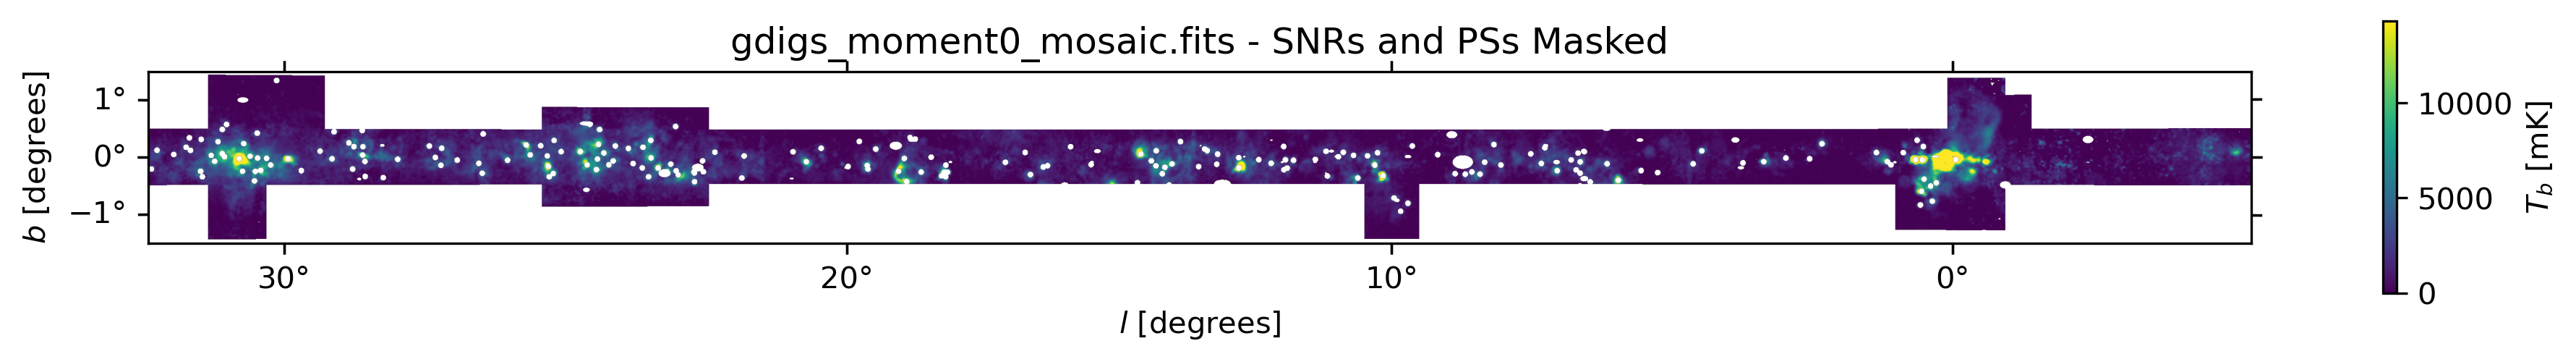

WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-TAN' 'GLAT-TAN' 
CRVAL : 14.791860982537 0.0 
CRPIX : 2168.9268966077 189.80767439907 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0083333333333333 0.0083333333333333 
NAXIS : 4643  378
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-TAN' 'GLAT-TAN' 
CRVAL : 16.0 0.0 
CRPIX : 1160.0 94.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.03333333333333333 0.03333333333333333 
NAXIS : 4643  378


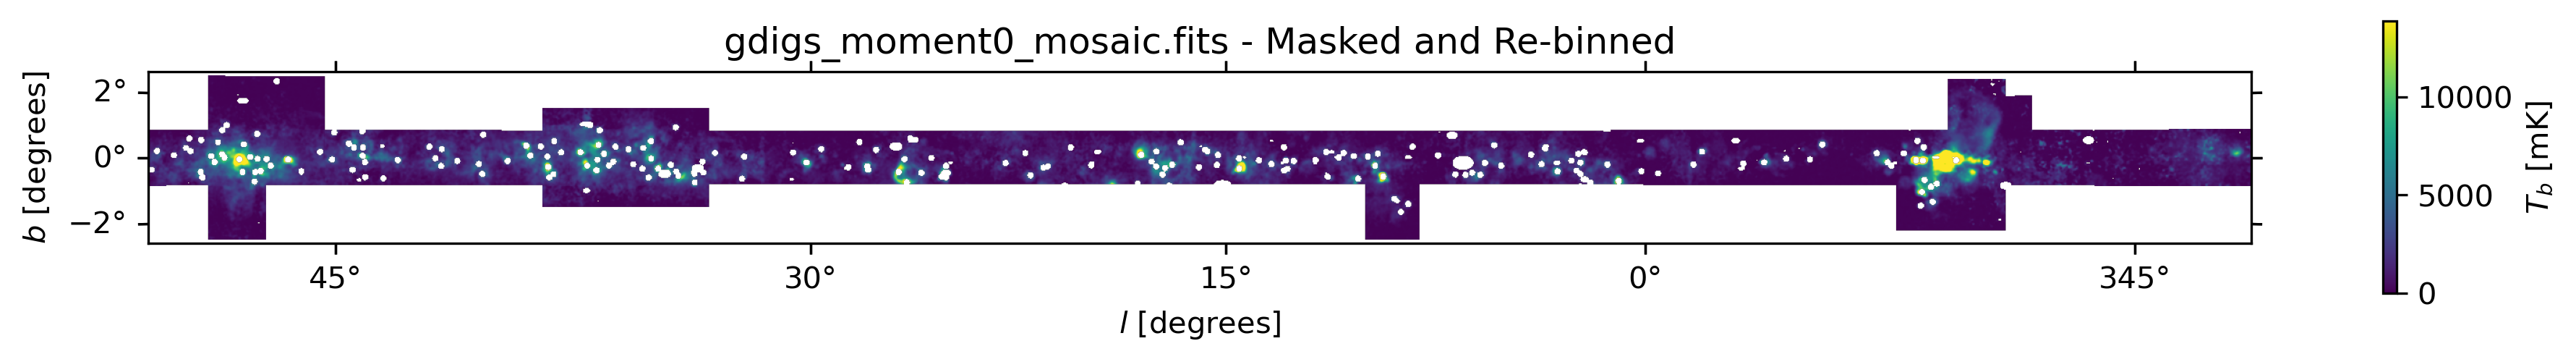

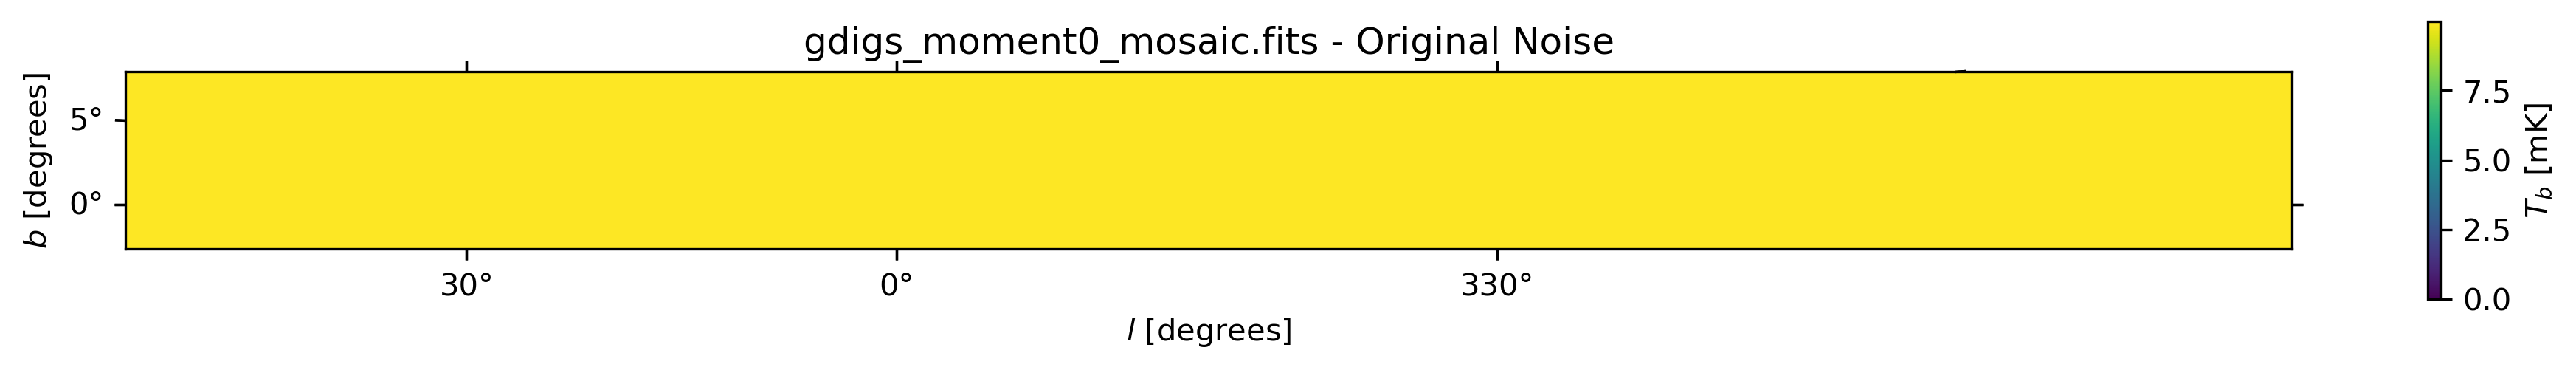

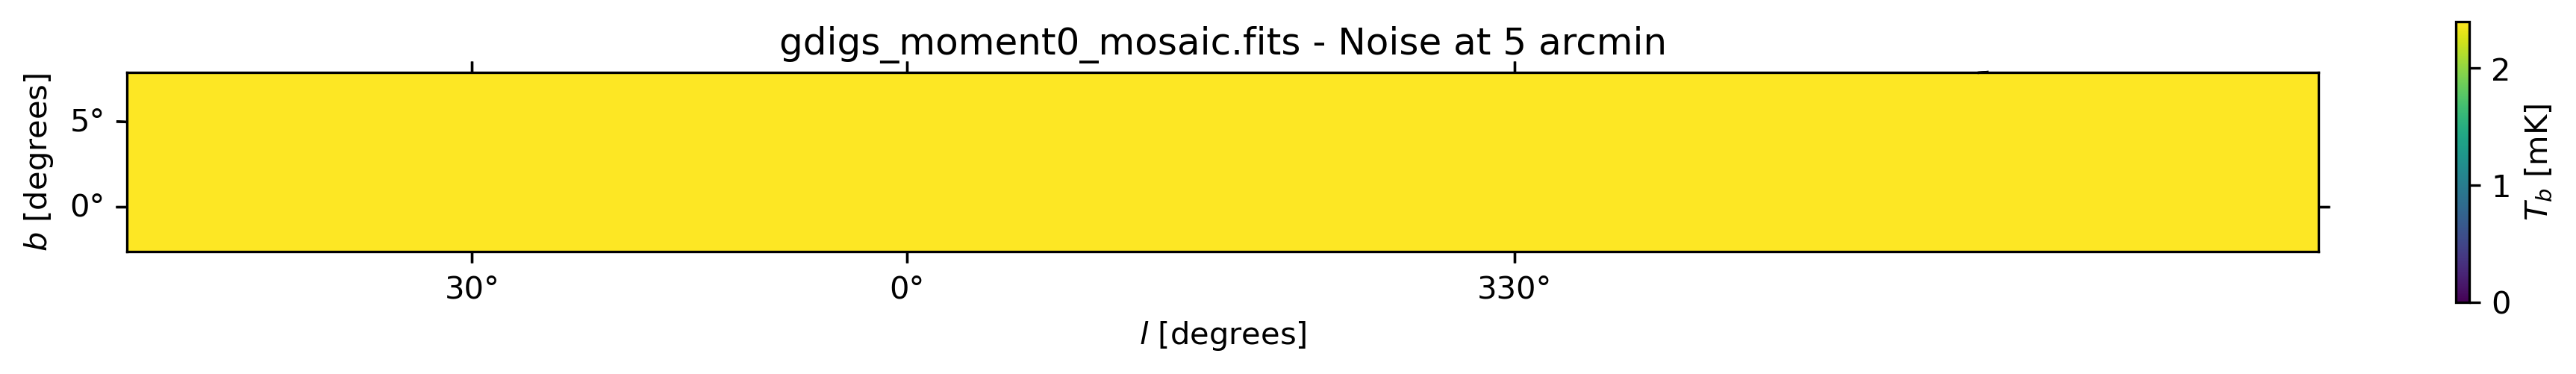

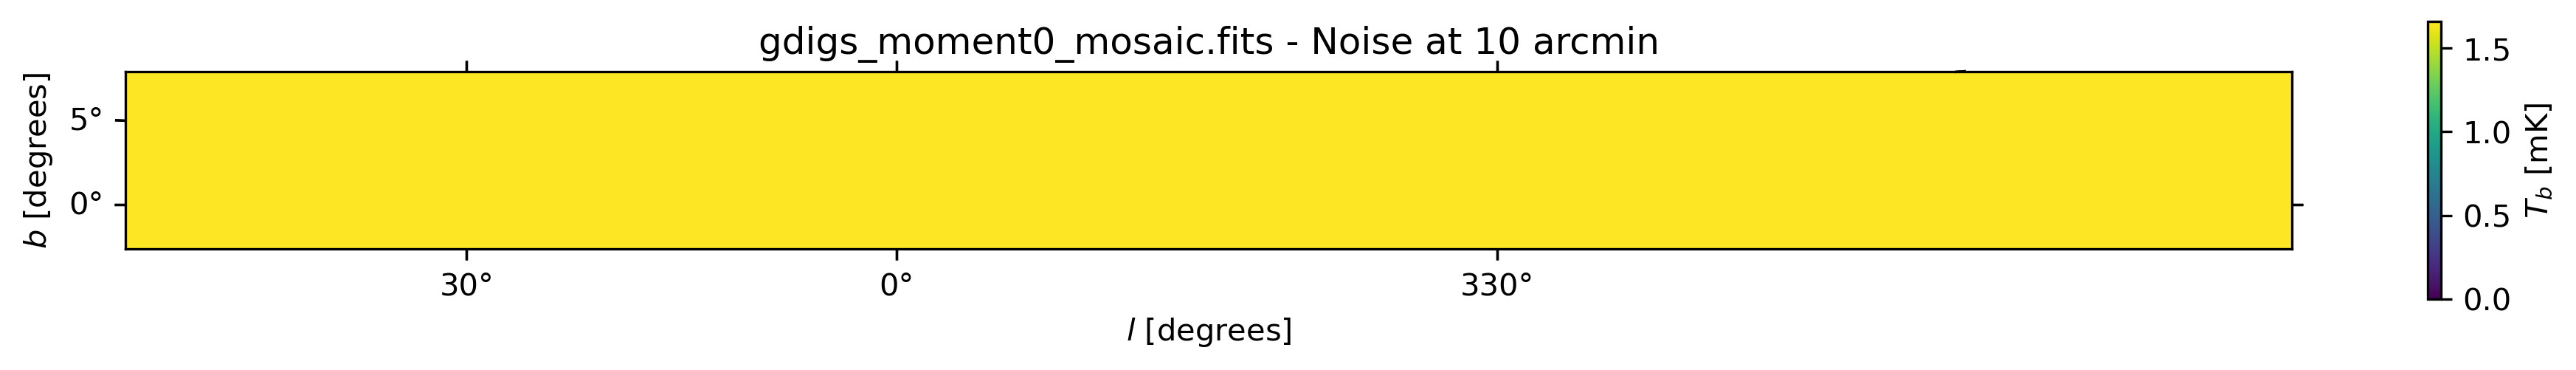

Getting data from /home/aimee/mphys/data/maps/EFFELSBERG-2.7272727272727275GHz-5.0amin.fits


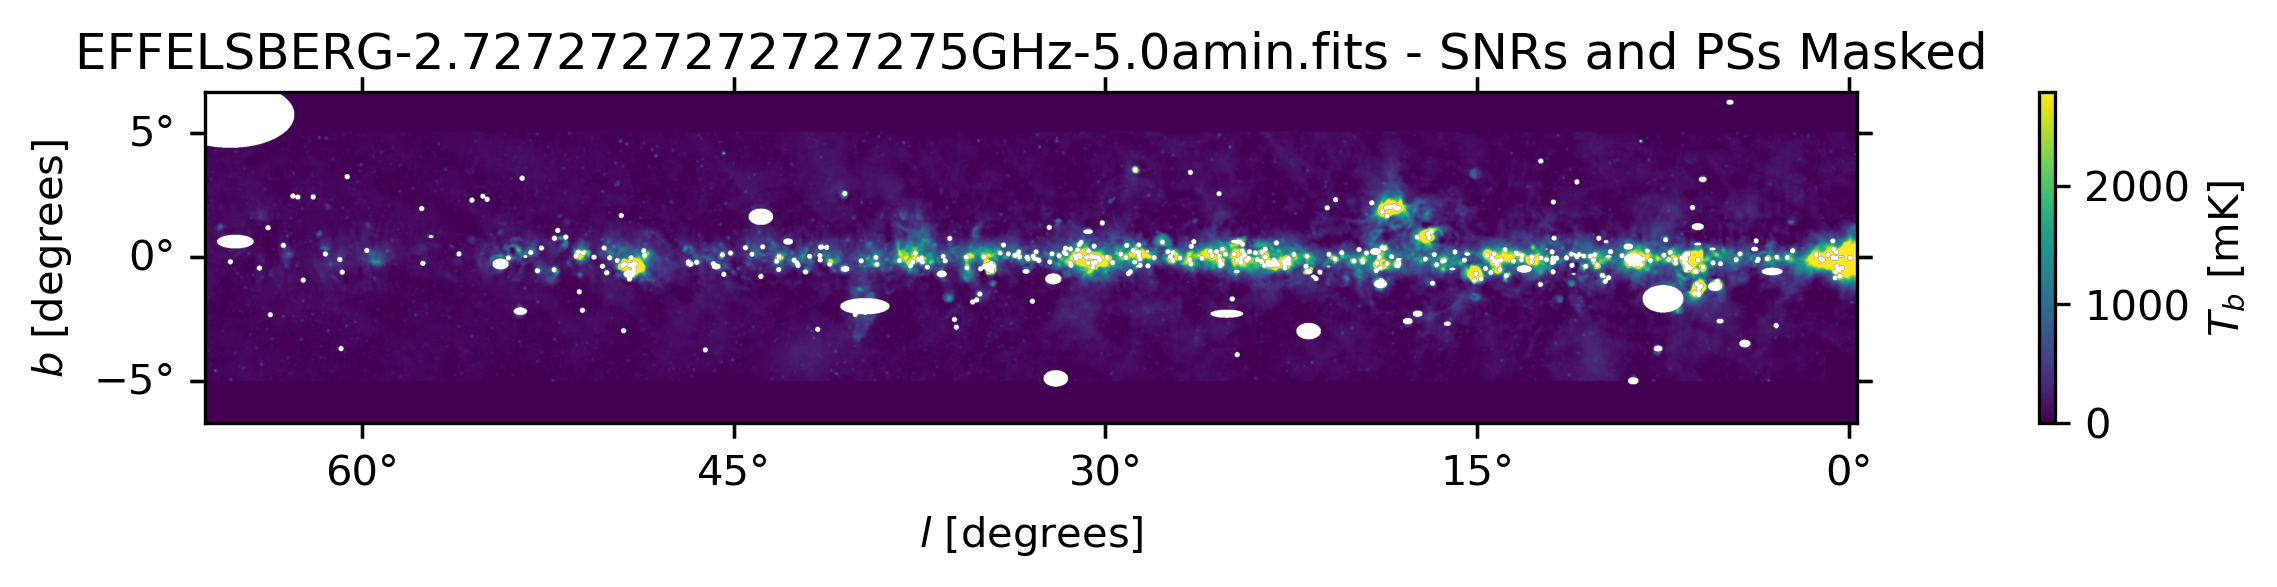

WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-CYP' 'GLAT-CYP' 
CRVAL : 33.0 0.0 
CRPIX : 2000.0 400.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.016666666666667 0.016666666666667 
NAXIS : 3999  799


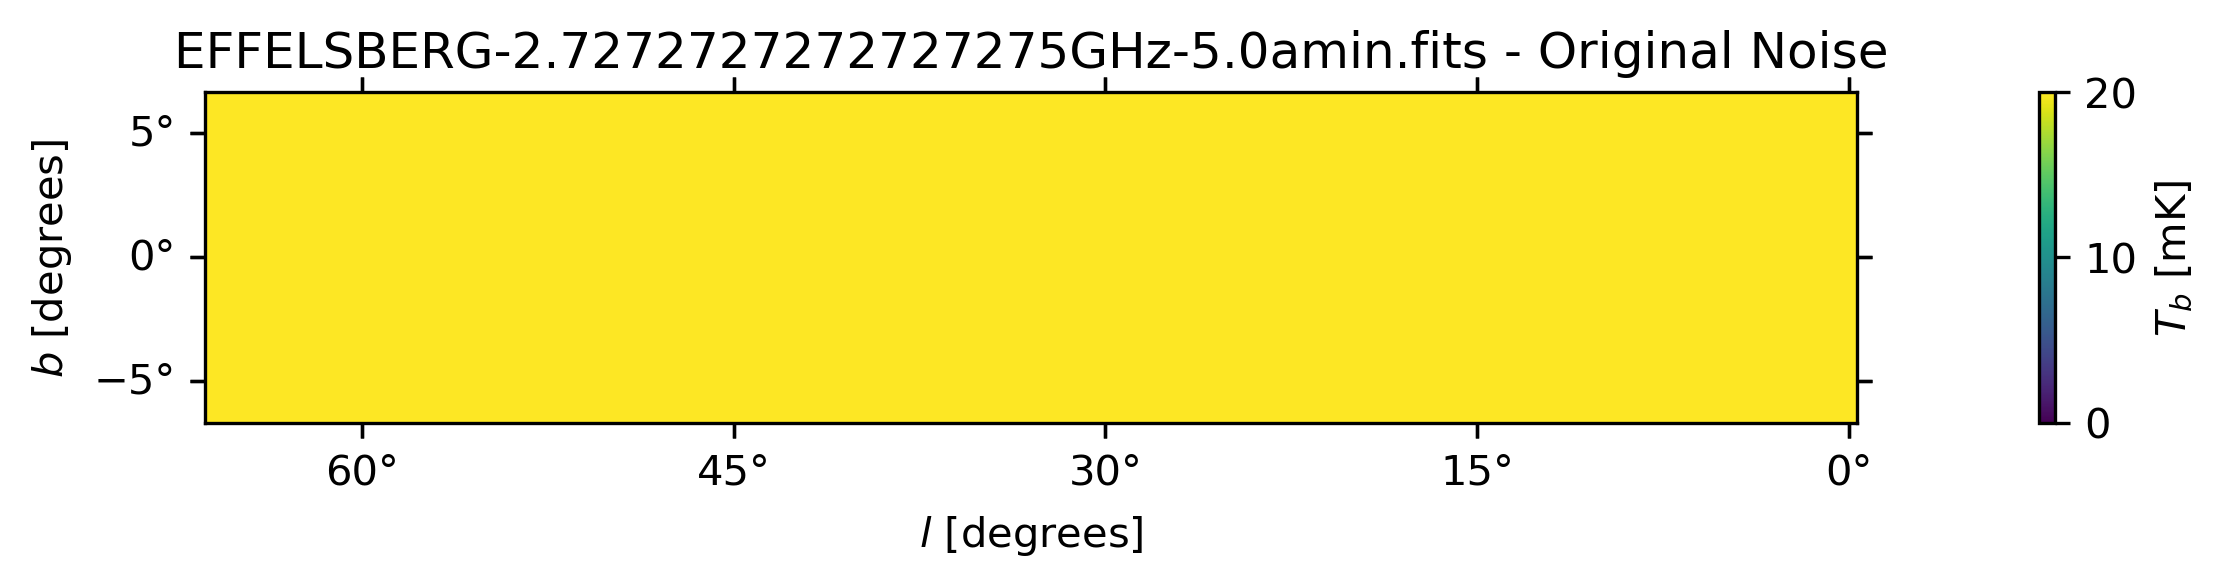

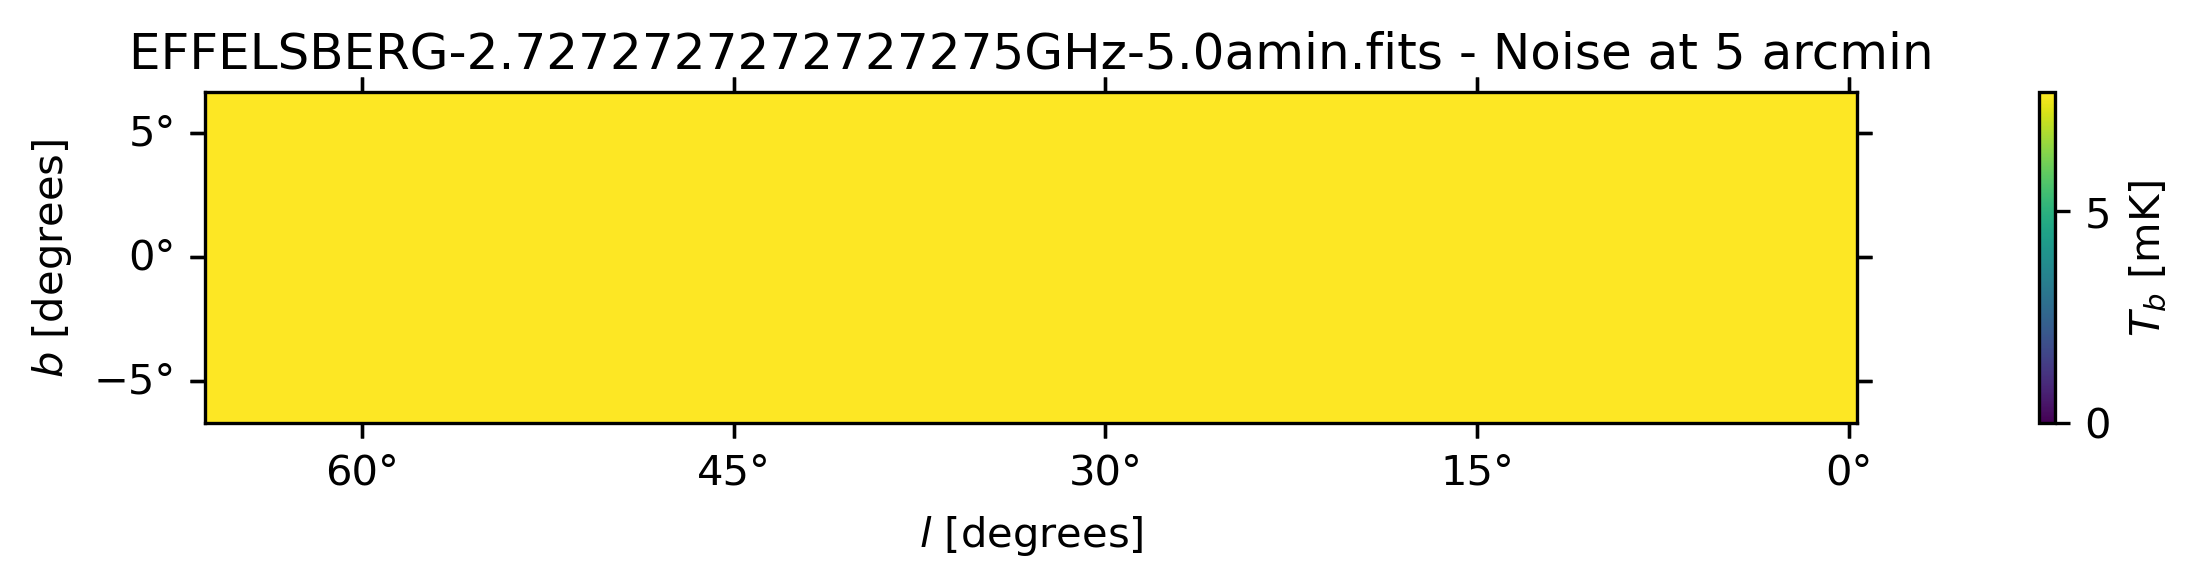

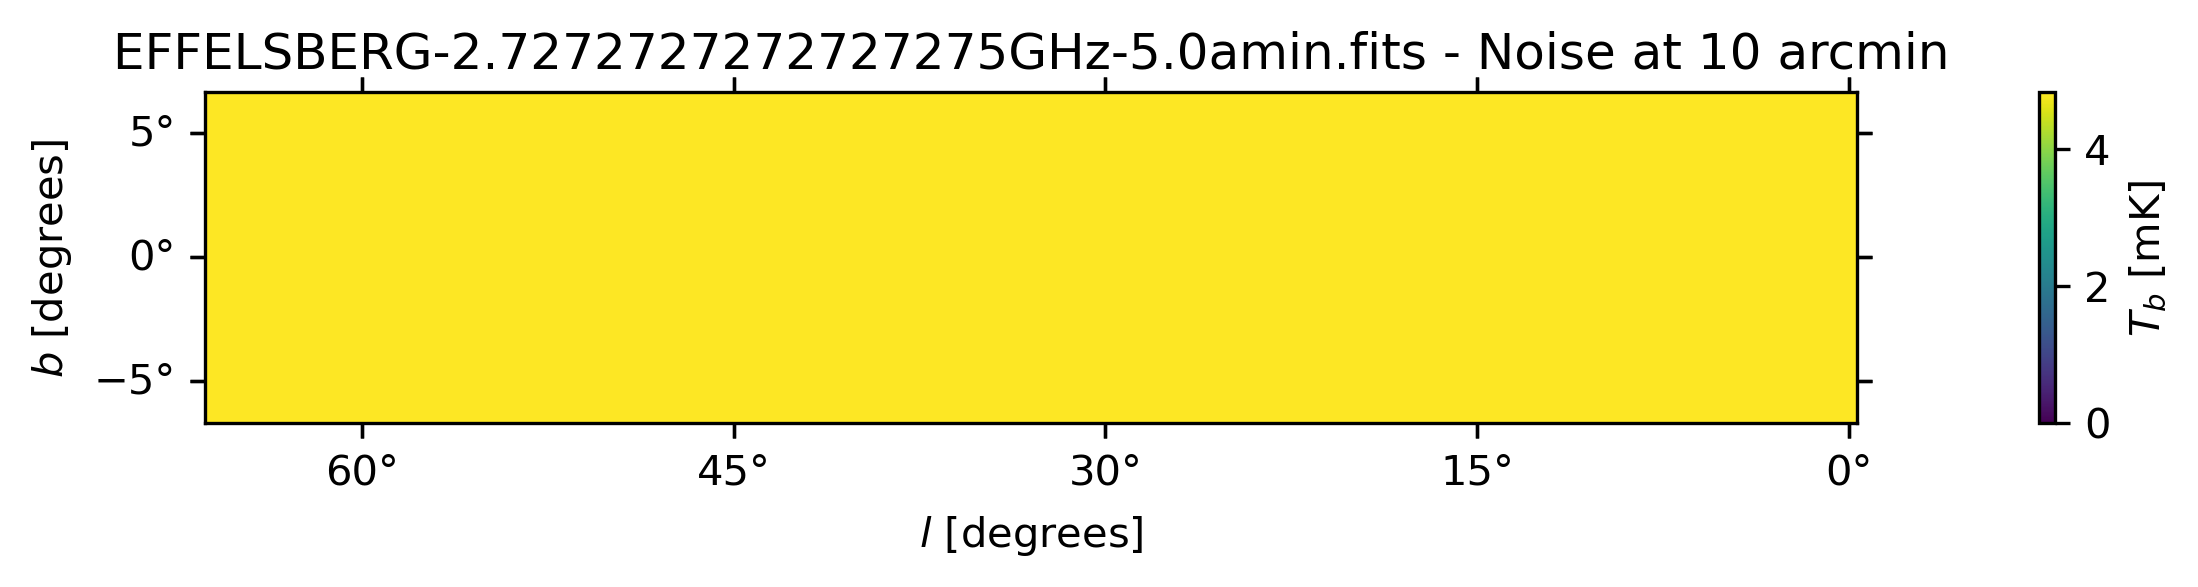

In [ ]:
# # --- MAIN CODE --- 

# # GDIGS (from mosaic)
# map_titles = list(GDIGS_MAPS.keys())
# noise_level_raw = 9.975 # mK
# noise_level_5_arcmin = 2.396 # mK 
# noise_level_10_arcmin = 1.658 # mK
# for map_title in map_titles:
#     map_name = GDIGS_MAPS[map_title][0]
#     frequency = GDIGS_MAPS[map_title][1]

#     map_path = f'{GDIGS_MOSAIC_DIR}/{map_name}'
#     data, noise, header, wcs = get_map(map_path)
#     # data, wcs, header = cut_data(data, wcs, header) # mild fudge, necessary for rebin_2D to work (with same L and B BOUNDS - see global variables)
#     noise = np.full_like(noise, noise_level_raw) # GDIGS map shape, not rectangle
#     data = convert_to_mK(map_title, data, frequency)
# #     data, noise, wcs, header = cut_data(data, noise, wcs, header)
    
#     main(data, wcs, header, noise, map_name, noise_level_5_arcmin=noise_level_5_arcmin, 
#          noise_level_10_arcmin=noise_level_10_arcmin, GDIGS=True, COMAP=False)

# # # COMAP (multiplicative noise - treat separately)
# # map_titles = list(COMAP_MAPS.keys())?
# # noise_level_5_arcmin = 0.391 # 39.1%
# # noise_level_10_arcmin = 0.241 # 24.1%
# # for map_title in map_titles:
# #     map_name = COMAP_MAPS[map_title][0]
# #     frequency = COMAP_MAPS[map_title][1]

# #     map_path = f'{OTHER_MAPS_DIR}/{map_name}'
# #     data, noise, header, wcs = get_map(map_path)
# #     data = convert_to_mK(map_title, data, frequency)
# # #     data, noise, wcs, header = cut_data(data, noise, wcs, header)
    
# #     main(data, wcs, header, noise, map_name, noise_level_5_arcmin=noise_level_5_arcmin, 
# #          noise_level_10_arcmin=noise_level_10_arcmin, GDIGS=False, COMAP=True)

# # EFFELSBERG    
# map_titles = list(EFFELSBERG_MAPS.keys())
# noise_level_raw = 20 # mK
# noise_level_5_arcmin = 7.820 # mK
# noise_level_10_arcmin = 4.827 # mK
# for map_title in map_titles:
#     map_name = EFFELSBERG_MAPS[map_title][0]
#     frequency = EFFELSBERG_MAPS[map_title][1]

#     map_path = f'{OTHER_MAPS_DIR}/{map_name}'
#     data, noise, header, wcs = get_map(map_path)
#     noise = np.full_like(noise, noise_level_raw)
#     data = convert_to_mK(map_title, data, frequency)
# #     data, noise, wcs, header = cut_data(data, noise, wcs, header)
    
#     main(data, wcs, header, noise, map_name, noise_level_5_arcmin=noise_level_5_arcmin, 
#          noise_level_10_arcmin=noise_level_10_arcmin, GDIGS=False, COMAP=False)

# # # NOBEYAMA
# # map_titles = list(NOBEYAMA_MAPS.keys())
# # noise_level_raw = 15 # mK
# # noise_level_5_arcmin = 5.232 # mK
# # noise_level_10_arcmin = 3.547 # mK
# # for map_title in map_titles:
# #     map_name = NOBEYAMA_MAPS[map_title][0]
# #     frequency = NOBEYAMA_MAPS[map_title][1]

# #     map_path = f'{OTHER_MAPS_DIR}/{map_name}'
# #     data, noise, header, wcs = get_map(map_path)
# #     noise = np.full_like(noise, noise_level_raw)
# #     data = convert_to_mK(map_title, data, frequency)
# # #     data, noise, wcs, header = cut_data(data, noise, wcs, header)
    
# #     main(data, wcs, header, noise, map_name, noise_level_5_arcmin=noise_level_5_arcmin, 
# #          noise_level_10_arcmin=noise_level_10_arcmin, GDIGS=False, COMAP=False)


# # # PARKES
# # map_titles = list(PARKES_MAPS.keys())
# # noise_level_raw = 49.44 # mK
# # noise_level_5_arcmin = 18.94 # mK
# # noise_level_10_arcmin = 11.89 # mK
# # for map_title in map_titles:
# #     map_name = PARKES_MAPS[map_title][0]
# #     frequency = PARKES_MAPS[map_title][1]

# #     map_path = f'{OTHER_MAPS_DIR}/{map_name}'
# #     data, noise, header, wcs = get_map(map_path)
# #     noise = np.full_like(noise, noise_level_raw)
# #     data = convert_to_mK(map_title, data, frequency)
# # #     data, noise, wcs, header = cut_data(data, noise, wcs, header)
    
# #     main(data, wcs, header, noise, map_name, noise_level_5_arcmin=noise_level_5_arcmin, 
# #          noise_level_10_arcmin=noise_level_10_arcmin, GDIGS=False, COMAP=False)

